## **Part A**

In [102]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import make_scorer, mean_absolute_percentage_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.linalg import toeplitz

In [103]:
df = pd.read_csv('/Users/lucasben/Documents/mba-business-analytics/courses/predictive-modelling/dataset_lm.csv')
df.head(5)

,Dependent Var,Explanatory Var #1,Explanatory Var #2,Explanatory Var #3,Explanatory Var #4,Explanatory Var #5,Explanatory Var #6,Explanatory Var #7,Explanatory Var #8,Explanatory Var #9,Explanatory Var #10,Explanatory Var #11,Explanatory Var #12,Explanatory Var #13,Explanatory Var #14,Explanatory Var #15
0,56.293458,13.698667,50.639873,0,-18.568035,45.121911,11.412501,56.410757,2,-12.281132,38.996909,-3.010548,49.195073,0,-21.153143,46.919314
1,58.473431,2.714725,65.845845,1,-25.105932,47.190213,10.080280,65.383107,3,-36.763585,51.654939,4.991111,45.591729,0,-6.474403,53.383508
2,94.195330,11.618072,65.072497,0,-7.897464,52.163036,11.057301,82.812717,0,-15.733547,48.913837,-2.457696,56.608806,0,-27.903299,48.515026
3,29.074583,0.818623,45.408996,1,-18.316132,54.356714,5.029029,48.812471,1,-12.825591,45.851732,14.974177,47.362594,1,-10.064411,55.266254
4,86.035569,9.077544,73.548021,0,-19.204165,47.186807,12.128134,62.520911,2,-13.804860,47.765904,9.593982,53.700562,0,-17.546302,48.150543


## **EDA**

In [104]:
df.isna().sum()

Dependent Var          0
Explanatory Var #1     0
Explanatory Var #2     0
Explanatory Var #3     0
Explanatory Var #4     0
Explanatory Var #5     0
Explanatory Var #6     0
Explanatory Var #7     0
Explanatory Var #8     0
Explanatory Var #9     0
Explanatory Var #10    0
Explanatory Var #11    0
Explanatory Var #12    0
Explanatory Var #13    0
Explanatory Var #14    0
Explanatory Var #15    0
dtype: int64

In [105]:
X = df.drop('Dependent Var', axis=1)
y = df['Dependent Var']
X = sm.add_constant(X) # adding intercept term

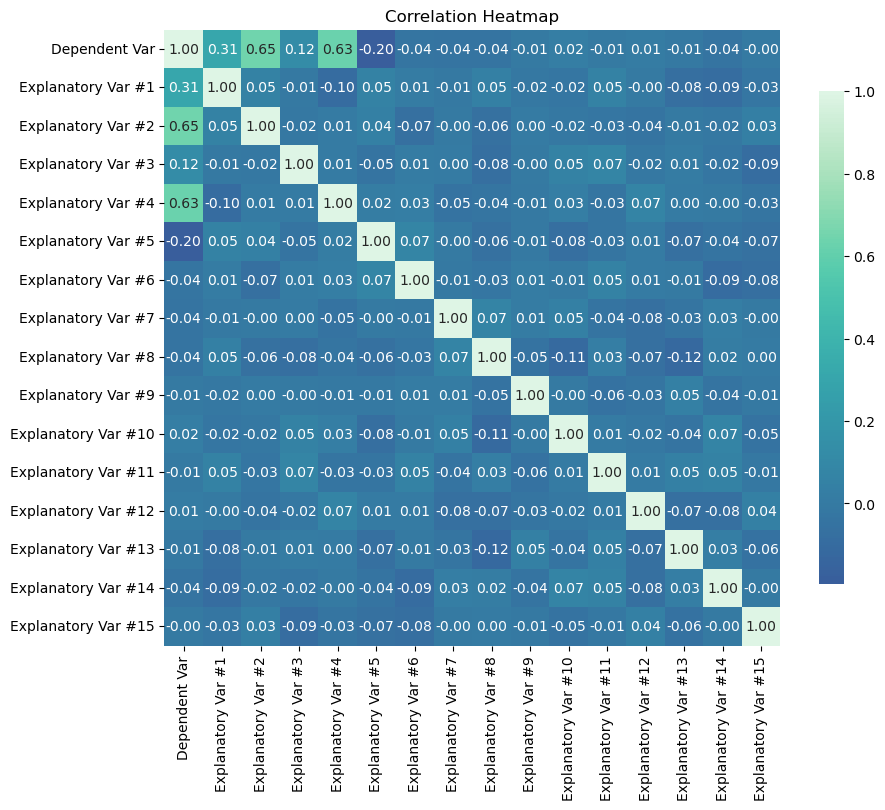

In [106]:
# correlation analysis
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt='.2f', # limiting output to 2 decimal places
            cmap='mako', # blue to green palette
            center=0, 
            square=True, 
            linewidths=0, # removing gridlines with '0'
            cbar_kws={"shrink": .8}) # shrinking the size of the legend for the heatmap
plt.title('Correlation Heatmap')
plt.show()

In [107]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Dependent Var   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.578e+30
Date:                Sun, 19 Oct 2025   Prob (F-statistic):               0.00
Time:                        11:17:46   Log-Likelihood:                 12180.
No. Observations:                 422   AIC:                        -2.433e+04
Df Residuals:                     406   BIC:                        -2.426e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.0000    6.3e-14   5.08e+14      0.000      32.000      32.000
Explanatory Var #1      1.3000   5.09e-16   2.56e+15      0.000       1.300       1.300
Explanatory Var #2      1.7000    3.7e-16    4.6e+15      0.000       1.700       1.700
Explanatory Var #3      6.2000   7.09e-15   8.74e+14      0.000       6.200       6.200
Explanatory Var #4      2.1000   4.37e-16   4.81e+15      0.000       2.100       2.100
Explanatory Var #5     -0.9000   5.12e-16  -1.76e+15      0.000      -0.900      -0.900
Explanatory Var #6  -3.636e-15   3.09e-16    -11.770      0.000   -4.24e-15   -3.03e-15
Explanatory Var #7  -8.674e-16   2.39e-16     -3.634      0.000   -1.34e-15   -3.98e-16
Explanatory Var #8  -5.218e-15   3.24e-15     -1.609      0.108   -1.16e-14    1.16e-15
Explanatory Var #9   3.187e-15   4.15e-16      7.685      0.000    2.37e-15       4e-15
Explanatory Var #10 -1.193e-15   5.17e-16     -2.309      0.021   -2.21e-15   -1.77e-16
Explanatory Var #11  3.962e-15      5e-16      7.927      0.000    2.98e-15    4.94e-15
Explanatory Var #12  5.829e-16   3.74e-16      1.559      0.120   -1.52e-16    1.32e-15
Explanatory Var #13  -2.62e-14   7.16e-15     -3.657      0.000   -4.03e-14   -1.21e-14
Explanatory Var #14  1.443e-15    4.4e-16      3.282      0.001    5.79e-16    2.31e-15
Explanatory Var #15 -1.721e-15   5.24e-16     -3.286      0.001   -2.75e-15   -6.91e-16
==============================================================================
Omnibus:                        0.895   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.639   Jarque-Bera (JB):                0.773
Skew:                          -0.102   Prob(JB):                        0.680
Kurtosis:                       3.050   Cond. No.                     2.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The Durbin-Watson test value from the OLS model is 1.894. A value under 2 indicates positive autocorrelation but it is likely insignificant. 

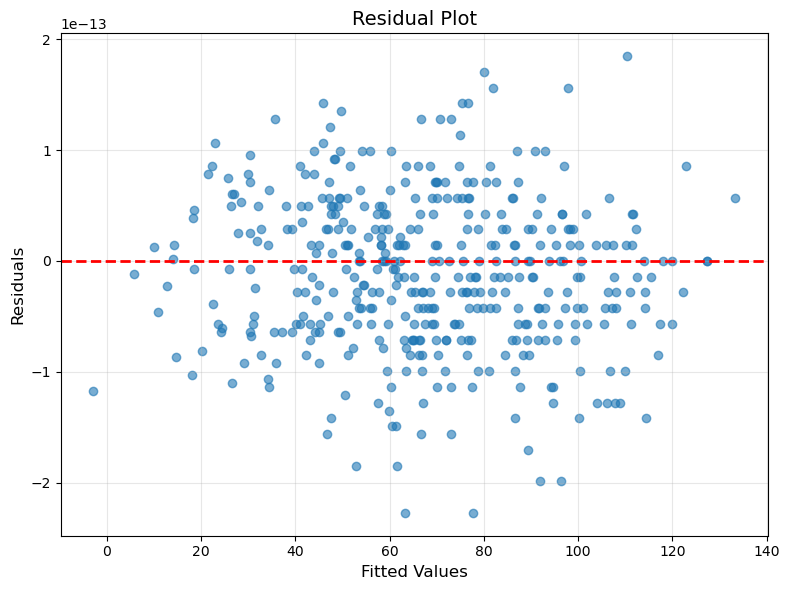

In [108]:
fig, ax = plt.subplots(figsize=(8, 6))

residuals = model.resid
ax.scatter(model.fittedvalues, residuals, alpha=0.6)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)

ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("Residuals", fontsize=12)
ax.set_title("Residual Plot", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Part B**

In [ ]:
# calculating the standard deviation of residuals
residual_std = np.sqrt(model.mse_resid)
print(f"Standard deviation of residuals: {residual_std:.15f}") 
# the near zero RMSE suggest near perfect multicollinearity and overfitting

Standard deviation of residuals: 0.000000000000072


In [ ]:
autocorrelations = acf(model.resid, nlags=3)

print("Autocorrelations:")
for lag, acf_value in enumerate(autocorrelations):
    print(f"Lag {lag}: {acf_value:.4f}")

Autocorrelations:
Lag 0: 1.0000
Lag 1: 0.0219
Lag 2: -0.0333
Lag 3: -0.0564


In [111]:
# estimating parameters from residuals
residuals = model.resid
rho = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
sigma_squared = np.var(residuals, ddof=1)
n = len(y)

cov_matrix = sigma_squared * toeplitz(rho ** np.arange(n))

gls_model = sm.GLS(y, X, sigma=cov_matrix)
gls_results = gls_model.fit()

In [112]:
gls_model = sm.GLS(y, X).fit()
gls_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:          Dependent Var   R-squared:                       1.000
Model:                            GLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.578e+30
Date:                Sun, 19 Oct 2025   Prob (F-statistic):               0.00
Time:                        11:17:46   Log-Likelihood:                 12180.
No. Observations:                 422   AIC:                        -2.433e+04
Df Residuals:                     406   BIC:                        -2.426e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.0000    6.3e-14   5.08e+14      0.000      32.000      32.000
Explanatory Var #1      1.3000   5.09e-16   2.56e+15      0.000       1.300       1.300
Explanatory Var #2      1.7000    3.7e-16    4.6e+15      0.000       1.700       1.700
Explanatory Var #3      6.2000   7.09e-15   8.74e+14      0.000       6.200       6.200
Explanatory Var #4      2.1000   4.37e-16   4.81e+15      0.000       2.100       2.100
Explanatory Var #5     -0.9000   5.12e-16  -1.76e+15      0.000      -0.900      -0.900
Explanatory Var #6  -3.636e-15   3.09e-16    -11.770      0.000   -4.24e-15   -3.03e-15
Explanatory Var #7  -8.674e-16   2.39e-16     -3.634      0.000   -1.34e-15   -3.98e-16
Explanatory Var #8  -5.218e-15   3.24e-15     -1.609      0.108   -1.16e-14    1.16e-15
Explanatory Var #9   3.187e-15   4.15e-16      7.685      0.000    2.37e-15       4e-15
Explanatory Var #10 -1.193e-15   5.17e-16     -2.309      0.021   -2.21e-15   -1.77e-16
Explanatory Var #11  3.962e-15      5e-16      7.927      0.000    2.98e-15    4.94e-15
Explanatory Var #12  5.829e-16   3.74e-16      1.559      0.120   -1.52e-16    1.32e-15
Explanatory Var #13  -2.62e-14   7.16e-15     -3.657      0.000   -4.03e-14   -1.21e-14
Explanatory Var #14  1.443e-15    4.4e-16      3.282      0.001    5.79e-16    2.31e-15
Explanatory Var #15 -1.721e-15   5.24e-16     -3.286      0.001   -2.75e-15   -6.91e-16
==============================================================================
Omnibus:                        0.895   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.639   Jarque-Bera (JB):                0.773
Skew:                          -0.102   Prob(JB):                        0.680
Kurtosis:                       3.050   Cond. No.                     2.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [113]:
# calculating VIF for each predictor
X = X.drop('const', axis=1) # dropping intercept
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
print(vif_data.sort_values('VIF', ascending=False))

                Feature        VIF
14  Explanatory Var #15  45.275012
4    Explanatory Var #5  42.640841
9   Explanatory Var #10  41.622662
11  Explanatory Var #12  36.394192
1    Explanatory Var #2  35.620462
6    Explanatory Var #7  17.773461
8    Explanatory Var #9   9.255962
13  Explanatory Var #14   5.370906
3    Explanatory Var #4   4.968174
7    Explanatory Var #8   3.026959
0    Explanatory Var #1   2.305255
10  Explanatory Var #11   2.239829
2    Explanatory Var #3   2.026868
12  Explanatory Var #13   2.006780
5    Explanatory Var #6   1.864960


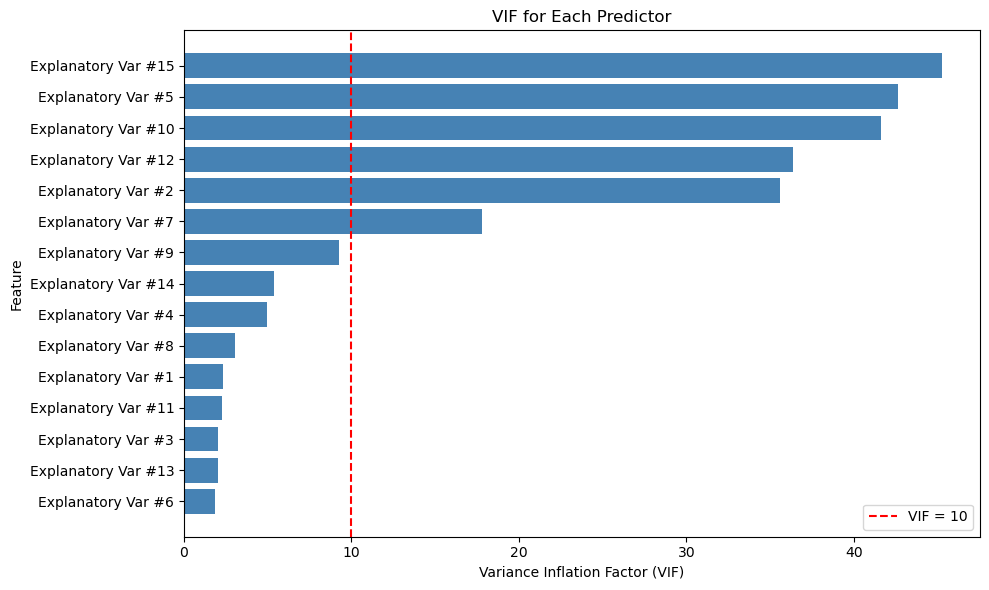

In [114]:
vif_data_sorted = vif_data.sort_values('VIF', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(vif_data_sorted['Feature'], vif_data_sorted['VIF'], color='steelblue')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10')

plt.xlabel('Variance Inflation Factor (VIF)')
plt.ylabel('Feature')
plt.title('VIF for Each Predictor')
plt.legend()
plt.tight_layout()
plt.show()

## **Part C**

In [115]:
X = sm.add_constant(X) # adding intercept term
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

In [116]:
lasso = make_pipeline(
        StandardScaler(),
        Lasso(
            alpha=1.0,
            fit_intercept=False,
            max_iter=5000
        ))
lasso.fit(X_train, y_train)

predictions = lasso.predict(X_test)
mape = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"Mean absolute percentage error: {mape:.2f}%")

Mean absolute percentage error: 138.08%


In [117]:
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

param_grid = {
    'alpha': np.logspace(-6, 2, 100)  
}

grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring=mape_scorer,        
    cv=5,                      
    verbose=1,                 
    n_jobs=-1,                  
    return_train_score=True     
)

grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['alpha']
best_mape_cv = -grid_search.best_score_ * 100 

print(f"Best Alpha: {best_alpha:.6f}")
print(f"Best MAPE (CV): {best_mape_cv:.2f}%")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


ValueError: Invalid parameter 'alpha' for estimator Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lasso', Lasso(fit_intercept=False, max_iter=5000))]). Valid parameters are: ['memory', 'steps', 'verbose'].

In [ ]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
test_mape = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"Test Set MAPE: {test_mape:.2f}%")

Test Set MAPE: 0.03%


## **Part D**

In [ ]:
data = {
    'Month': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    'Demand': [100, 112, 107, 103, 91, 85, 84, 85, 79, 81, 134, 86, 99, 89, 111, 114, 118, 163, 193, 143, 144, 202, 158, 160, 144],
    'Advance Demand': [71, 30, 75, 64, 41, 51, 42, 51, 57, 49, 134, 52, 99, 56, 81, 79, 73, 163, 193, 99, 91, 202, 105, 101, 96]
}
data = pd.DataFrame(data)
transposed_data = data.T

In [ ]:
if isinstance(transposed_data, pd.DataFrame):
    for col in transposed_data.columns:
        autocorr = acf(transposed_data[col], nlags=1)
        print(f"{col}: First-order autocorrelation = {autocorr[1]:.3f}")

0: First-order autocorrelation = -0.351
1: First-order autocorrelation = -0.627
2: First-order autocorrelation = -0.362
3: First-order autocorrelation = -0.425
4: First-order autocorrelation = -0.551
5: First-order autocorrelation = -0.452
6: First-order autocorrelation = -0.529
7: First-order autocorrelation = -0.460
8: First-order autocorrelation = -0.367
9: First-order autocorrelation = -0.466
10: First-order autocorrelation = -0.167
11: First-order autocorrelation = -0.472
12: First-order autocorrelation = -0.167
13: First-order autocorrelation = -0.459
14: First-order autocorrelation = -0.366
15: First-order autocorrelation = -0.398
16: First-order autocorrelation = -0.463
17: First-order autocorrelation = -0.167
18: First-order autocorrelation = -0.167
19: First-order autocorrelation = -0.399
20: First-order autocorrelation = -0.452
21: First-order autocorrelation = -0.167
22: First-order autocorrelation = -0.424
23: First-order autocorrelation = -0.454
24: First-order autocorrel

In [ ]:
# creating training and test set for new data
split_point = int(len(data) * 0.8)
train = data.iloc[:split_point]
test = data.iloc[split_point:]
X_train = train[['Advance Demand']]
y_train = train['Demand']
X_test = test[['Advance Demand']]
y_test = test['Demand']

In [ ]:
lasso_model = make_pipeline(
    StandardScaler(), 
    LassoCV(
        alphas=[0.001, 0.01, 0.1, 1, 10], 
        cv=5,
        max_iter=10000,
        random_state=42
    )
)

lasso_model.fit(X_train, y_train)
pred = lasso_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, pred) * 100 
print("Best alpha (λ):", lasso_model.named_steps['lassocv'].alpha_)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))
print("MAPE:", round(mape, 2), "%")

Best alpha (λ): 0.001
RMSE: 27.654
MAPE: 17.0 %
